In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
loss_0 = pd.read_csv(r"..\results\run_0\loss_history.csv")
loss_1 = pd.read_csv(r"..\results\run_1\loss_history.csv")
loss_2 = pd.read_csv(r"..\results\run_2\loss_history.csv")
loss_3 = pd.read_csv(r"..\results\run_3\loss_history.csv")
loss_4 = pd.read_csv(r"..\results\run_4\loss_history.csv")
loss_6 = pd.read_csv(r"..\results\run_6\loss_history.csv")
loss_7 = pd.read_csv(r"..\results\run_7\loss_history.csv")

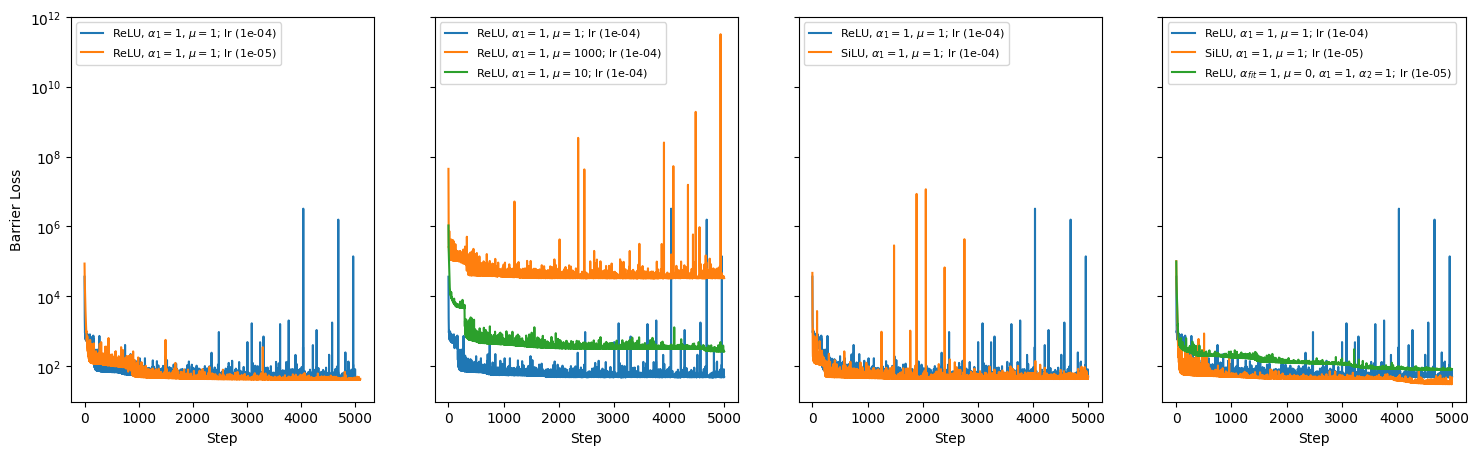

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(18,5), sharey=True)

ax[0].plot(loss_0['epoch'], loss_0['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-04)")
ax[0].plot(loss_2['epoch'], loss_2['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-05)")
ax[0].set_yscale("log")
ax[0].set_ylabel("Barrier Loss")
ax[0].set_xlabel('Step')
ax[0].legend(loc='upper left', fontsize=8)

ax[1].plot(loss_0['epoch'], loss_0['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-04)")
ax[1].plot(loss_1['epoch'], loss_1['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=1000$; $\mathrm{lr}$ (1e-04)")
ax[1].plot(loss_7['epoch'], loss_7['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=10$; $\mathrm{lr}$ (1e-04)")
ax[1].set_yscale("log")
ax[1].set_xlabel('Step')
ax[1].legend(loc='upper left', fontsize=8)

ax[2].plot(loss_0['epoch'], loss_0['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-04)")
ax[2].plot(loss_3['epoch'], loss_3['train_loss'], label=r"SiLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-04)")
ax[2].set_yscale("log")
ax[2].set_xlabel('Step')
ax[2].legend(loc='upper left', fontsize=8)

ax[3].plot(loss_0['epoch'], loss_0['train_loss'], label=r"ReLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-04)")
ax[3].plot(loss_4['epoch'], loss_4['train_loss'], label=r"SiLU, $\alpha_1=1$, $\mu=1$; $\mathrm{lr}$ (1e-05)")
ax[3].plot(loss_6['epoch'], loss_6['train_loss'], label=r"ReLU, $\alpha_{fit}=1$, $\mu=0$, $\alpha_1=1$, $\alpha_2=1$; $\mathrm{lr}$ (1e-05)")
ax[3].set_yscale("log")
ax[3].set_xlabel('Step')
ax[3].legend(loc='upper left', fontsize=8)

plt.show()


In [2]:
import numpy as np
from numcodecs import Blosc

In [3]:
npz_true = np.load(r"..\data\DEMs\test\20260415_0300.npz")

In [5]:
LogT = [5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2]

In [6]:
compressor = Blosc(cname='zstd', clevel=4, shuffle=2)

In [7]:
dem_true = np.frombuffer(
        compressor.decode(npz_true["DEMCube"]),
        dtype=np.float32
    ).reshape(npz_true["DEMCubeShape"])

aia = np.frombuffer(
        compressor.decode(npz_true["AIACube"]),
        dtype=np.float32
    ).reshape(npz_true["AIACubeShape"])

In [8]:
dem_true.shape

(18, 32, 32)

In [9]:
npz_run0 = np.load(r"..\data\DEMs\pred\20260415_0300\run_0.npz")
npz_run1 = np.load(r"..\data\DEMs\pred\20260415_0300\run_1.npz")
npz_run2 = np.load(r"..\data\DEMs\pred\20260415_0300\run_2.npz")
npz_run3 = np.load(r"..\data\DEMs\pred\20260415_0300\run_3.npz")
npz_run4 = np.load(r"..\data\DEMs\pred\20260415_0300\run_4.npz")
npz_run5 = np.load(r"..\data\DEMs\pred\20260415_0300\run_5.npz")
npz_run6 = np.load(r"..\data\DEMs\pred\20260415_0300\run_6.npz")
npz_run7 = np.load(r"..\data\DEMs\pred\20260415_0300\run_7.npz")

In [11]:
n_runs = 8
data_dir = r"..\data\DEMs\pred\20260415_0300"  # ajusta esto

dem_preds = {}
for i in range(n_runs):
    npz = np.load(f"{data_dir}/run_{i}.npz")
    dem_preds[f"run{i}"] = npz['DEMCube']
    print(f"dem_pred_run{i}.shape = {dem_preds[f'run{i}'].shape}")


dem_pred_run0.shape = (18, 32, 32)
dem_pred_run1.shape = (18, 32, 32)
dem_pred_run2.shape = (18, 32, 32)
dem_pred_run3.shape = (18, 32, 32)
dem_pred_run4.shape = (18, 32, 32)
dem_pred_run5.shape = (18, 32, 32)
dem_pred_run6.shape = (18, 32, 32)
dem_pred_run7.shape = (18, 32, 32)


In [13]:
dem_preds.keys()

dict_keys(['run0', 'run1', 'run2', 'run3', 'run4', 'run5', 'run6', 'run7'])

In [14]:
plt.rcParams["figure.dpi"] = 500
plt.rcParams["text.usetex"] = True
plt.rcParams['font.family'] = 'serif'

In [15]:
def style_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)

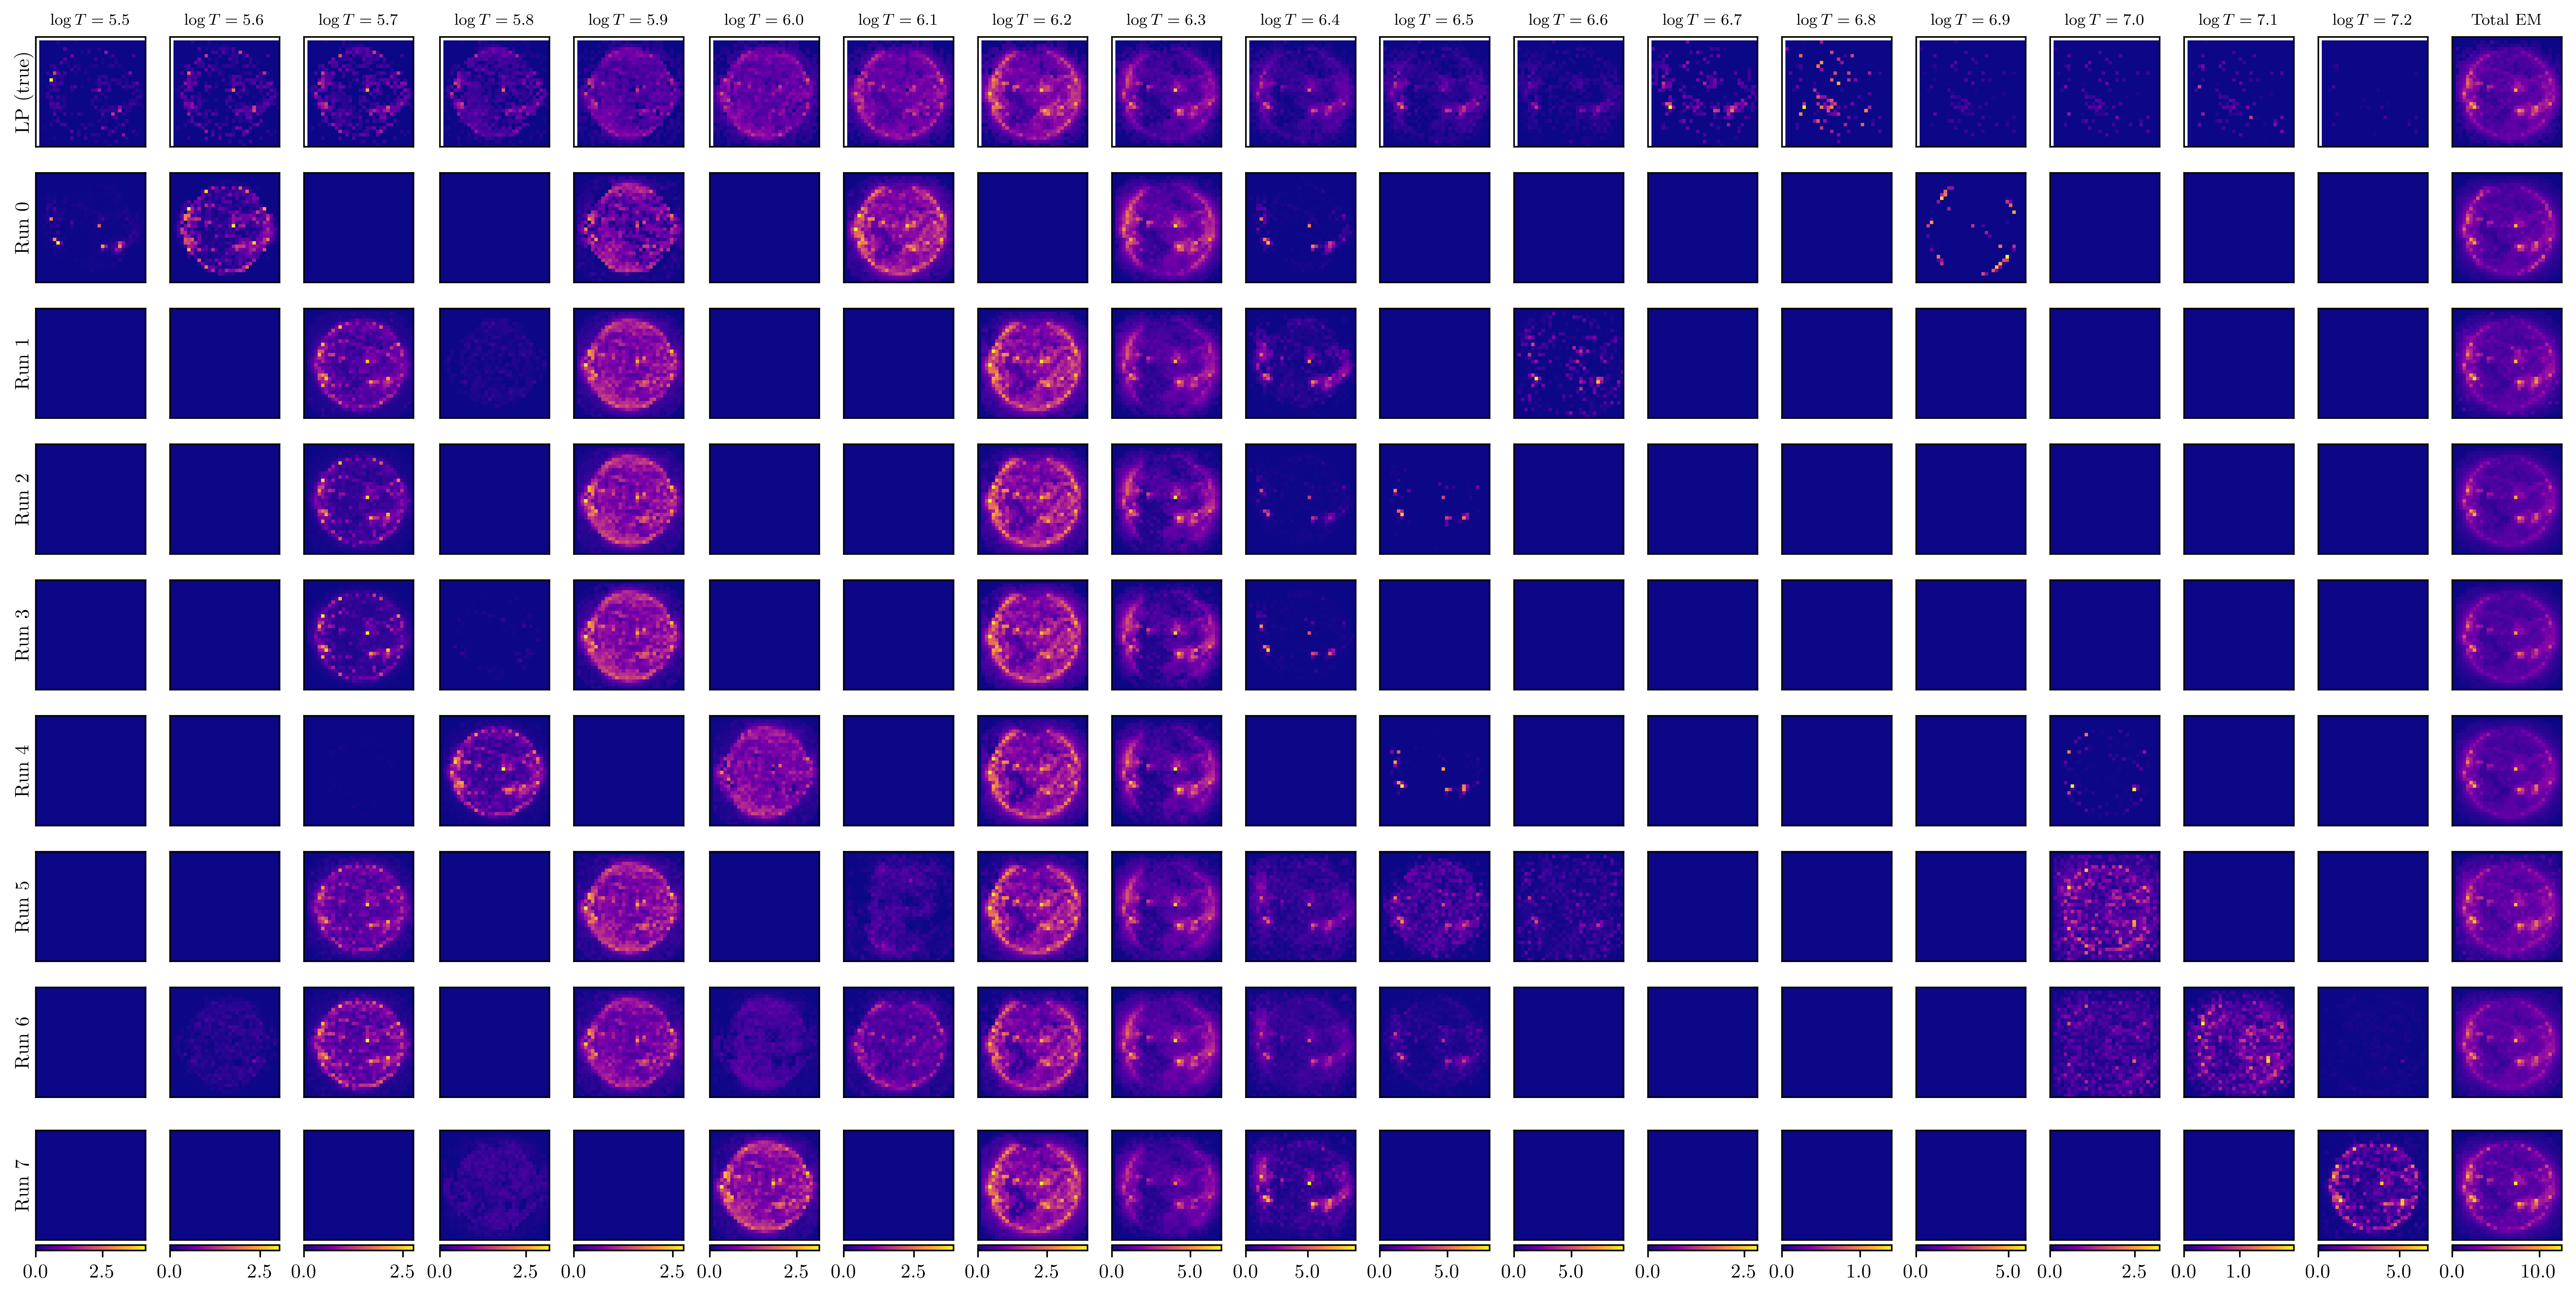

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Lista de cubos a graficar: (cubo, etiqueta)
dem_cubes = [(dem_true, "LP (true)")] + [
    (dem_preds[f"run{i}"], f"Run {i}") for i in range(n_runs)
]

n_rows = len(dem_cubes)
n_bins = dem_true.shape[0]  # 18
n_cols = n_bins + 1  # +1 por la columna de Total EM

cmap = 'plasma'

# --- Precalcular datos transformados (sqrt) y límites por columna ---
transformed = []
for cube, label in dem_cubes:
    total_em = np.nansum(cube, axis=0)
    row_data = [cube[ch]**0.5 for ch in range(n_bins)] + [total_em**0.5]
    transformed.append(row_data)

# vmin/vmax por columna, recorriendo todas las filas (nan-safe)
col_vmin = [min(np.nanmin(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]
col_vmax = [max(np.nanmax(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, n_rows), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.02, wspace=0.05)

for row, (cube, label) in enumerate(dem_cubes):
    for col in range(n_cols):
        im = ax[row, col].imshow(
            transformed[row][col],
            cmap=cmap,
            vmin=col_vmin[col],
            vmax=col_vmax[col],
        )
        style_ax(ax[row, col])

        if row == n_rows - 1:
            fig.colorbar(im, ax=ax[row, col], format='%.1f', orientation='horizontal',
                         fraction=0.046, pad=0.04)

        if row == 0:
            if col < n_bins:
                ax[row, col].set_title(fr"$\log T = {LogT[col]:.1f}$", fontsize=8)
            else:
                ax[row, col].set_title("Total EM", fontsize=8)

    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                           rotation=90, labelpad=6, va='center')

plt.show()

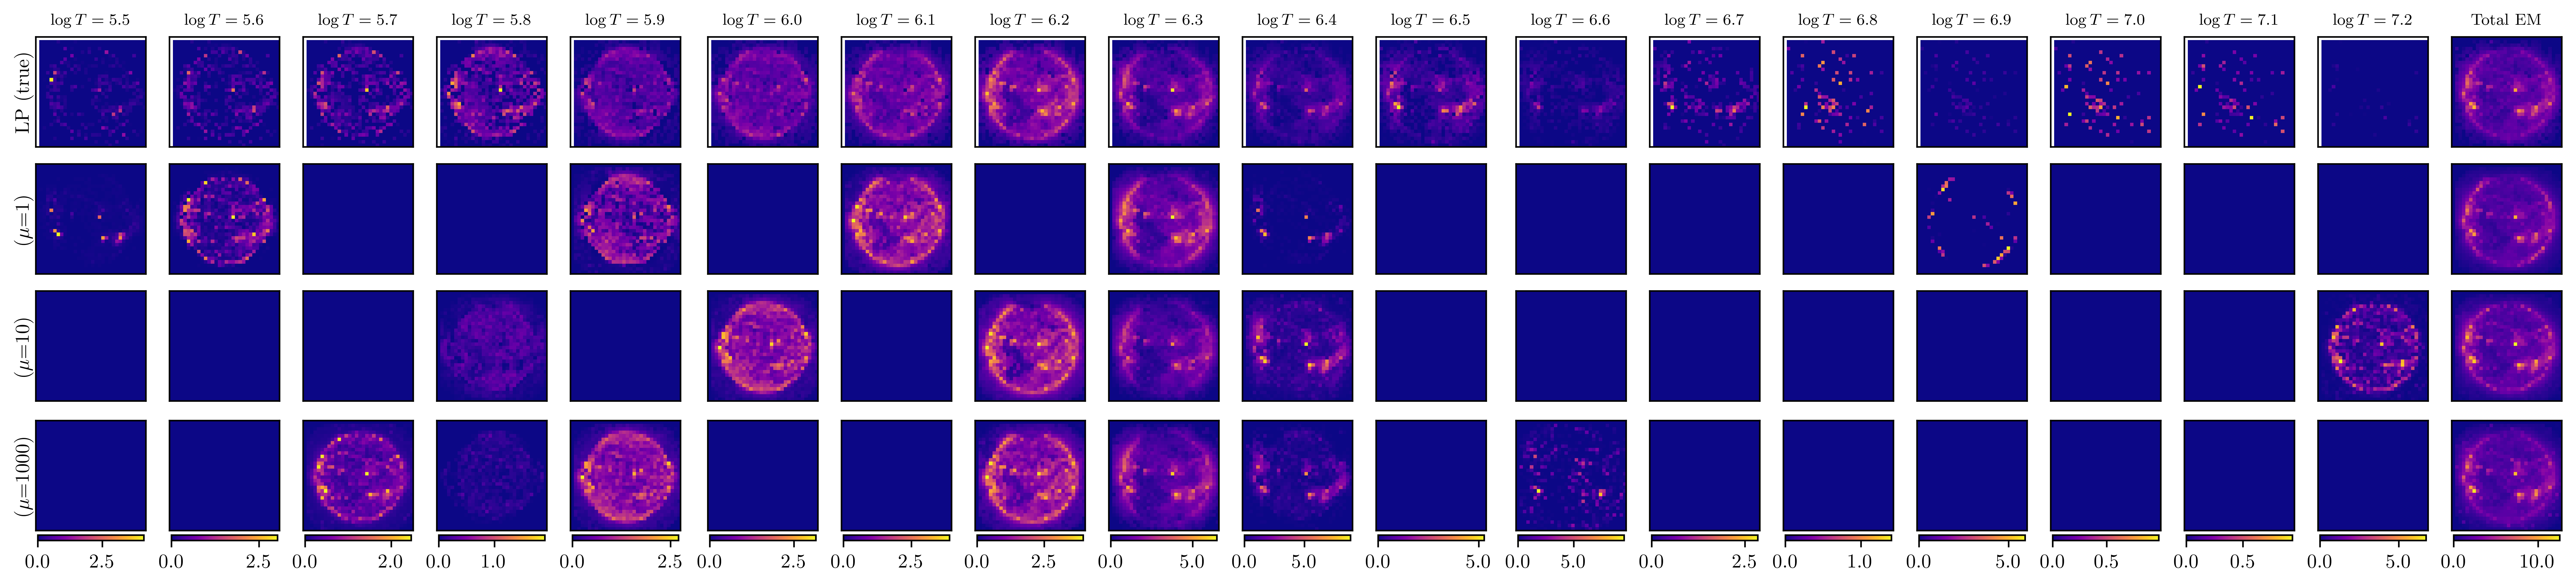

In [20]:
# Runs y sus mu correspondientes (mismo orden)
run_ids = [0, 7, 1]
mu_values = [1, 10, 1000]

# Lista de cubos a graficar: (cubo, etiqueta)
dem_cubes = [(dem_true, "LP (true)")] + [
    (dem_preds[f"run{i}"], r"($\mu$=" + f"{mu})")
    for i, mu in zip(run_ids, mu_values)
]

n_rows = len(dem_cubes)
n_bins = dem_true.shape[0]  # 18
n_cols = n_bins + 1  # +1 por la columna de Total EM

cmap = 'plasma'

# --- Precalcular datos transformados (sqrt) y límites por columna ---
transformed = []
for cube, label in dem_cubes:
    total_em = np.nansum(cube, axis=0)
    row_data = [cube[ch]**0.5 for ch in range(n_bins)] + [total_em**0.5]
    transformed.append(row_data)

# vmin/vmax por columna, recorriendo todas las filas (nan-safe)
col_vmin = [min(np.nanmin(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]
col_vmax = [max(np.nanmax(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, n_rows), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.02, wspace=0.05)

for row, (cube, label) in enumerate(dem_cubes):
    for col in range(n_cols):
        im = ax[row, col].imshow(
            transformed[row][col],
            cmap=cmap,
            vmin=col_vmin[col],
            vmax=col_vmax[col],
        )
        style_ax(ax[row, col])

        if row == n_rows - 1:
            fig.colorbar(im, ax=ax[row, col], format='%.1f', orientation='horizontal',
                         fraction=0.046, pad=0.04)

        if row == 0:
            if col < n_bins:
                ax[row, col].set_title(fr"$\log T = {LogT[col]:.1f}$", fontsize=8)
            else:
                ax[row, col].set_title("Total EM", fontsize=8)

    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                           rotation=90, labelpad=6, va='center')

plt.show()

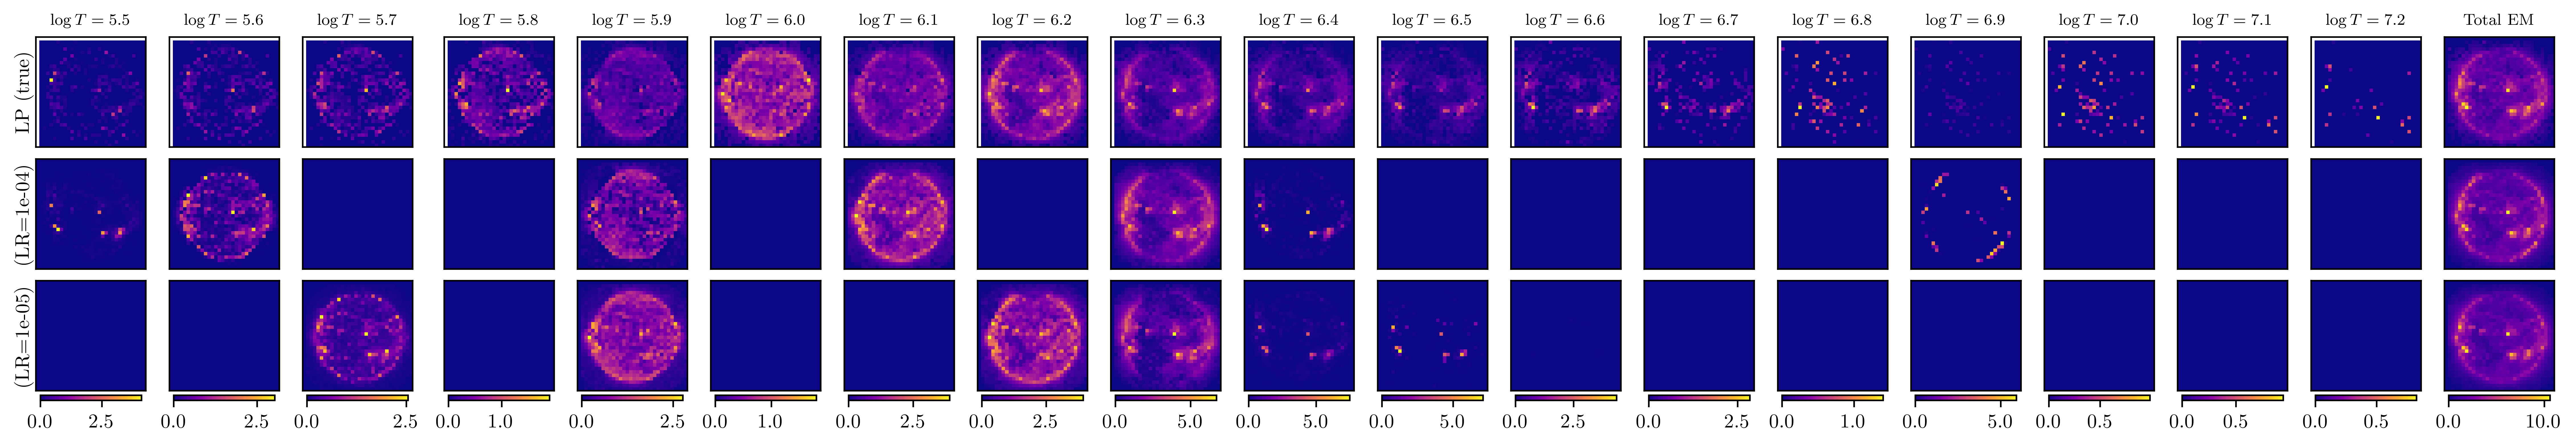

In [26]:
# Runs y sus lambda correspondientes (mismo orden)
run_ids = [0, 2]
lambda_values = [1e-4, 1e-5]

# Lista de cubos a graficar: (cubo, etiqueta)
dem_cubes = [(dem_true, "LP (true)")] + [
    (dem_preds[f"run{i}"], r"(LR=" + f"{l:.0e})")
    for i, l in zip(run_ids, lambda_values)
]

n_rows = len(dem_cubes)
n_bins = dem_true.shape[0]  # 18
n_cols = n_bins + 1  # +1 por la columna de Total EM

cmap = 'plasma'

# --- Precalcular datos transformados (sqrt) y límites por columna ---
transformed = []
for cube, label in dem_cubes:
    total_em = np.nansum(cube, axis=0)
    row_data = [cube[ch]**0.5 for ch in range(n_bins)] + [total_em**0.5]
    transformed.append(row_data)

# vmin/vmax por columna, recorriendo todas las filas (nan-safe)
col_vmin = [min(np.nanmin(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]
col_vmax = [max(np.nanmax(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, n_rows), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.02, wspace=0.05)

for row, (cube, label) in enumerate(dem_cubes):
    for col in range(n_cols):
        im = ax[row, col].imshow(
            transformed[row][col],
            cmap=cmap,
            vmin=col_vmin[col],
            vmax=col_vmax[col],
        )
        style_ax(ax[row, col])

        if row == n_rows - 1:
            fig.colorbar(im, ax=ax[row, col], format='%.1f', orientation='horizontal',
                         fraction=0.046, pad=0.04)

        if row == 0:
            if col < n_bins:
                ax[row, col].set_title(fr"$\log T = {LogT[col]:.1f}$", fontsize=8)
            else:
                ax[row, col].set_title("Total EM", fontsize=8)

    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                           rotation=90, labelpad=6, va='center')

plt.show()

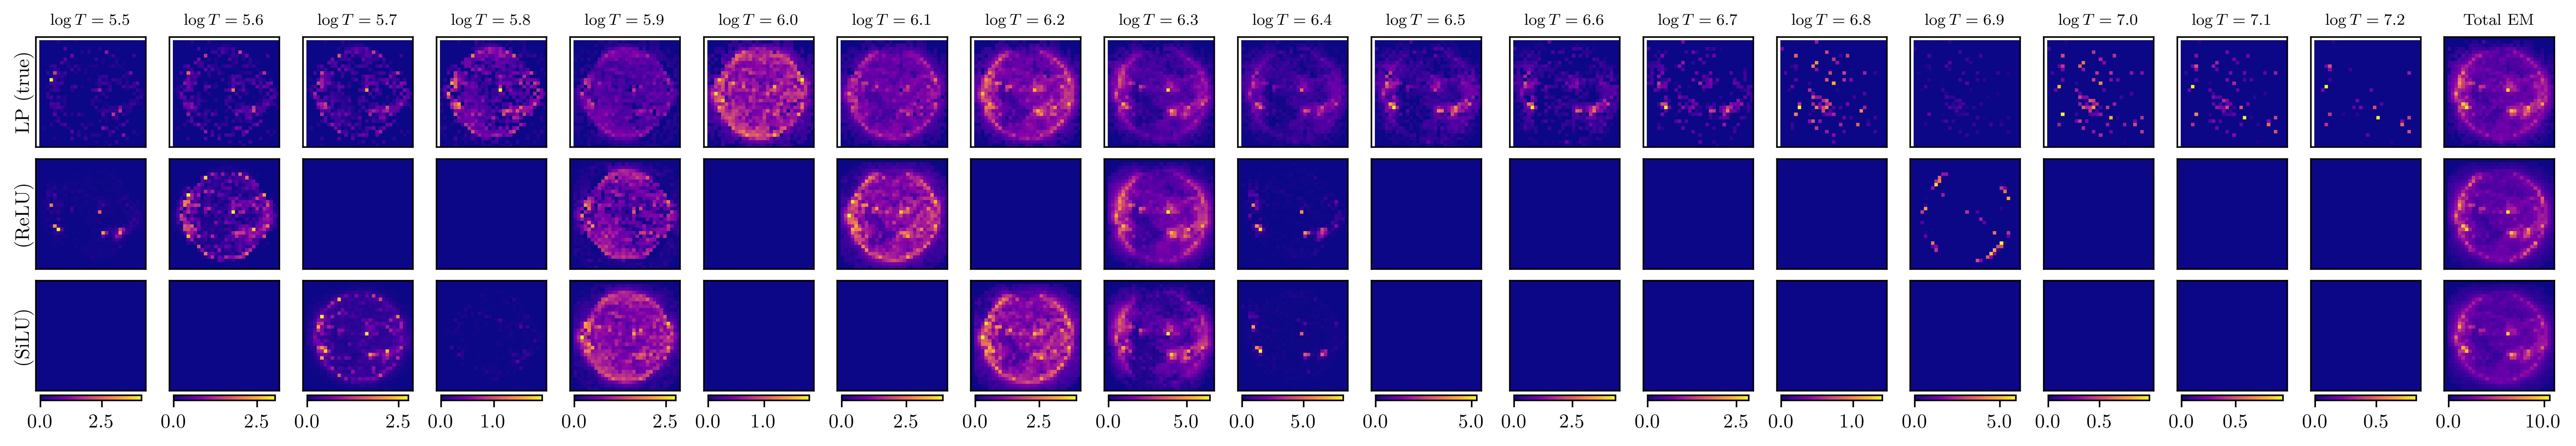

In [28]:
# Runs y sus activaciones correspondientes (mismo orden)
run_ids = [0, 3]
activations = ['ReLU', 'SiLU']

# Lista de cubos a graficar: (cubo, etiqueta)
dem_cubes = [(dem_true, "LP (true)")] + [
    (dem_preds[f"run{i}"], f"({act})")
    for i, act in zip(run_ids, activations)
]

n_rows = len(dem_cubes)
n_bins = dem_true.shape[0]  # 18
n_cols = n_bins + 1  # +1 por la columna de Total EM

cmap = 'plasma'

# --- Precalcular datos transformados (sqrt) y límites por columna ---
transformed = []
for cube, label in dem_cubes:
    total_em = np.nansum(cube, axis=0)
    row_data = [cube[ch]**0.5 for ch in range(n_bins)] + [total_em**0.5]
    transformed.append(row_data)

# vmin/vmax por columna, recorriendo todas las filas (nan-safe)
col_vmin = [min(np.nanmin(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]
col_vmax = [max(np.nanmax(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, n_rows), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.02, wspace=0.05)

for row, (cube, label) in enumerate(dem_cubes):
    for col in range(n_cols):
        im = ax[row, col].imshow(
            transformed[row][col],
            cmap=cmap,
            vmin=col_vmin[col],
            vmax=col_vmax[col],
        )
        style_ax(ax[row, col])

        if row == n_rows - 1:
            fig.colorbar(im, ax=ax[row, col], format='%.1f', orientation='horizontal',
                         fraction=0.046, pad=0.04)

        if row == 0:
            if col < n_bins:
                ax[row, col].set_title(fr"$\log T = {LogT[col]:.1f}$", fontsize=8)
            else:
                ax[row, col].set_title("Total EM", fontsize=8)

    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                           rotation=90, labelpad=6, va='center')

plt.show()

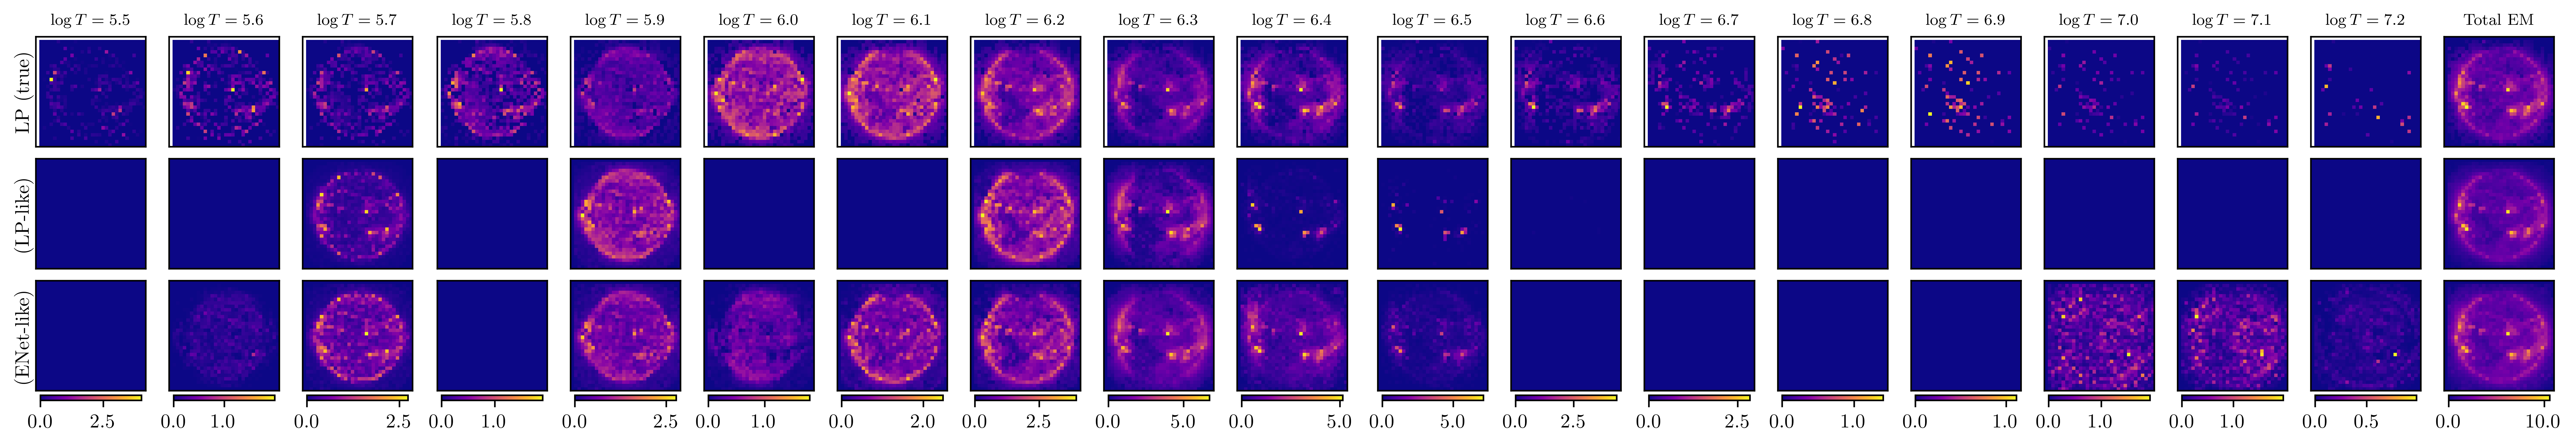

In [33]:
# Runs y sus activaciones correspondientes (mismo orden)
run_ids = [2, 6]
activations = ['LP-like', 'ENet-like']

# Lista de cubos a graficar: (cubo, etiqueta)
dem_cubes = [(dem_true, "LP (true)")] + [
    (dem_preds[f"run{i}"], f"({act})")
    for i, act in zip(run_ids, activations)
]

n_rows = len(dem_cubes)
n_bins = dem_true.shape[0]  # 18
n_cols = n_bins + 1  # +1 por la columna de Total EM

cmap = 'plasma'

# --- Precalcular datos transformados (sqrt) y límites por columna ---
transformed = []
for cube, label in dem_cubes:
    total_em = np.nansum(cube, axis=0)
    row_data = [cube[ch]**0.5 for ch in range(n_bins)] + [total_em**0.5]
    transformed.append(row_data)

# vmin/vmax por columna, recorriendo todas las filas (nan-safe)
col_vmin = [min(np.nanmin(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]
col_vmax = [max(np.nanmax(transformed[row][col]) for row in range(n_rows)) for col in range(n_cols)]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(18, n_rows), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.02, wspace=0.05)

for row, (cube, label) in enumerate(dem_cubes):
    for col in range(n_cols):
        im = ax[row, col].imshow(
            transformed[row][col],
            cmap=cmap,
            vmin=col_vmin[col],
            vmax=col_vmax[col],
        )
        style_ax(ax[row, col])

        if row == n_rows - 1:
            fig.colorbar(im, ax=ax[row, col], format='%.1f', orientation='horizontal',
                         fraction=0.046, pad=0.04)

        if row == 0:
            if col < n_bins:
                ax[row, col].set_title(fr"$\log T = {LogT[col]:.1f}$", fontsize=8)
            else:
                ax[row, col].set_title("Total EM", fontsize=8)

    ax[row, 0].set_ylabel(label, fontsize=10, fontweight='bold',
                           rotation=90, labelpad=6, va='center')

plt.show()